In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [11]:
def load_train_val():
    # Load data
    df = pd.read_csv("mnist_train.csv")

    # Separate features and labels
    x = df.iloc[:, 1:].values  # pixels
    y = df.iloc[:, 0].values  # labels

    # Keep original shape (28x28) for later (for NN)
    X_images = x.reshape(-1, 1, 28, 28)

    # Stratified split (60/20/20)
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.83, stratify=y, random_state=42)

    return x_train, x_val, y_train, y_val

In [15]:
def load_test():
    # Load data
    df = pd.read_csv("mnist_test.csv")

    # Separate features and labels
    x_test = df.iloc[:, 1:].values  # pixels
    y_test = df.iloc[:, 0].values  # labels

    # Keep original shape (28x28) for later (for NN)
    X_images = x_test.reshape(-1, 1, 28, 28)

    return x_test, y_test

In [16]:
def normalize(x):
  return x/255.0

In [17]:
x_train, x_val, y_train, y_val = load_train_val()
print(x_train.max(), x_train.min())
x_test, y_test = load_test()

x_train = normalize(x_train)
x_val = normalize(x_val)
x_test = normalize(x_test)

# Convert to tensors
x_train_t = torch.tensor(x_train, dtype=torch.float32 )
y_train_t = torch.tensor(y_train, dtype=torch.float32 )
x_val_t   = torch.tensor(x_val, dtype=torch.float32   )
y_val_t   = torch.tensor(y_val, dtype=torch.float32   )
x_test_t  = torch.tensor(x_test, dtype=torch.float32  )
y_test_t  = torch.tensor(y_test, dtype=torch.float32  )

# Keep only digits 0 and 1
binary_mask = (y_train_t == 0) | (y_train_t == 1)
x_train_bin = x_train_t[binary_mask]

y_train_bin = y_train_t[binary_mask]
print(x_train_bin.max(), x_train_bin.min())

binary_mask_val = (y_val_t == 0) | (y_val_t == 1)
x_val_bin = x_val_t[binary_mask_val]
y_val_bin = y_val_t[binary_mask_val]

binary_mask = (y_test_t == 0) | (y_test_t == 1)
x_test_bin = x_test_t[binary_mask]
y_test_bin = y_test_t[binary_mask]

# Create Datasets and Loaders
train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)
test_dataset = TensorDataset(x_test_t, y_test_t)


train_dataset_binary = TensorDataset(x_train_bin, y_train_bin)
val_dataset_binary = TensorDataset(x_val_bin, y_val_bin)
test_dataset_binary = TensorDataset(x_test_bin, y_test_bin)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

train_loader_binary = DataLoader(train_dataset_binary, batch_size=10, shuffle=True)
val_loader_binary = DataLoader(val_dataset_binary, batch_size=10)
test_loader_binary = DataLoader(test_dataset_binary, batch_size=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)


255 0
tensor(1.) tensor(0.)
Device: cpu


# The Variables here

In [18]:
# Training loop
lr = 0.01
epochs = 20

In [19]:
def cross_entropy_loss(y_batch,y_pred):
    return -torch.mean(y_batch * torch.log(y_pred + 1e-8) + (1 - y_batch) * torch.log(1 - y_pred + 1e-8))


# The Logistic Classification Training ALgorithm

In [20]:
def train_logistic(loader,lr,epochs = 100,plot=False):
# Initialize parameters
  train_losses = []
  W = torch.zeros(784, 1, dtype=torch.float32, requires_grad=True, device = device)
  b = torch.zeros(1, requires_grad=True, device = device)

  for epoch in range(epochs):
      epoch_loss = 0
      batch_loss = 0
      for x_batch, y_batch in loader:
          x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1)
          if W.grad is not None:
            W.grad.zero_()
            b.grad.zero_()
          # Forward pass
          y_pred = torch.sigmoid(x_batch @ W + b)
          # Backprop
          loss = cross_entropy_loss(y_batch=y_batch,y_pred=y_pred)
          batch_size = x_batch.size(0)  # actual number of samples in this batch
          epoch_loss += loss.item() * batch_size  # weight by batch size
          loss.backward()
          # Save copy for diff *after* backward but before update
          # Update
          with torch.no_grad():
              W.data -= lr * W.grad
              b.data -= lr * b.grad

      avg_loss = epoch_loss / len(loader.dataset)
      if (epoch/epochs*100)%25 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.10f}")

      # Average loss per epoch
      train_losses.append(avg_loss)
  if plot:
    plt.plot(train_losses, label="Training Loss", color='blue')
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()
  print("Training done!")
  return W,b;

Epoch 1, Loss: 0.1673744562
Epoch 26, Loss: 0.0086534882
Epoch 51, Loss: 0.0056245831
Epoch 76, Loss: 0.0042868668
Epoch 100, Loss: 0.0035282638


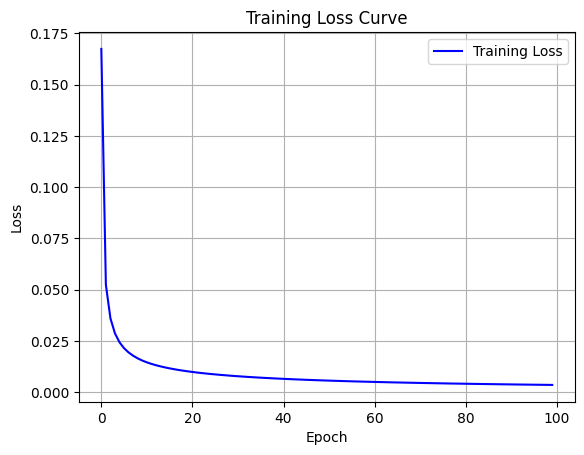

Training done!


In [21]:
W, b = train_logistic(train_loader_binary,lr=0.01,plot=True)

# Logistic Test

In [22]:
def test_logistic_model(W, b, test_loader,cm_print = False):
    W = W.to(device)
    b = b.to(device)
    total = 0
    correct = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1)

            # Forward pass
            y_pred = torch.sigmoid(x_batch @ W + b)

            # --- Compute Cross Entropy Loss ---
            loss = cross_entropy_loss(y_batch=y_batch,y_pred=y_pred)
            batch_size = x_batch.size(0)  # actual number of samples in this batch
            total_loss += loss.item() * batch_size  # weight by batch size

            # Convert probabilities to binary class labels
            predicted = (y_pred >= 0.5).float()
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

            all_preds.append(predicted.cpu())
            all_labels.append(y_batch.cpu())

    # Combine all predictions
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    accuracy = correct / total
    mean_ce = total_loss / len(test_loader.dataset)

    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print(f"Test Cross-Entropy Loss: {mean_ce:.4f}")

    if cm_print:
      cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
      print("Confusion Matrix:\n", cm)
    return mean_ce

# Validation Algorithm

In [30]:
def validate(train_func,test_func,train_loader,val_loader,epochs = 100 , plot = False):
  lrs = [0.001,0.01,0.1,1.0]
  lrs = np.array(lrs)
  all_losses = list()
  best_lr = None
  for lr in lrs:
    print(f"Testing lr:{lr}")
    W, b = train_func(train_loader,lr=lr,epochs = epochs,plot=True)
    loss = test_func(W,b,val_loader) # Pass cm_print=False during validation
    all_losses.append(loss)
    print()
  all_losses = np.array(all_losses)
  best_idx = np.nanargmin(all_losses)
  best_lr= lrs[best_idx]
  best_loss = all_losses[best_idx]
  print(f"Best learning rate: {best_lr:.3e}    Validation CE: {best_loss:.6f}")
  if plot:
      plt.plot(lrs, all_losses)
      plt.xscale('log')
      plt.xlabel('learning rate')
      plt.ylabel('Validation CE')
      plt.title('Validation CE vs learning rate')
      plt.grid(True)
      plt.show()

  return best_lr

Testing lr:0.001
Epoch 1, Loss: 0.4794207072
Epoch 51, Loss: 0.0224710232
Epoch 101, Loss: 0.0148167981
Epoch 151, Loss: 0.0117113055
Epoch 200, Loss: 0.0099355052


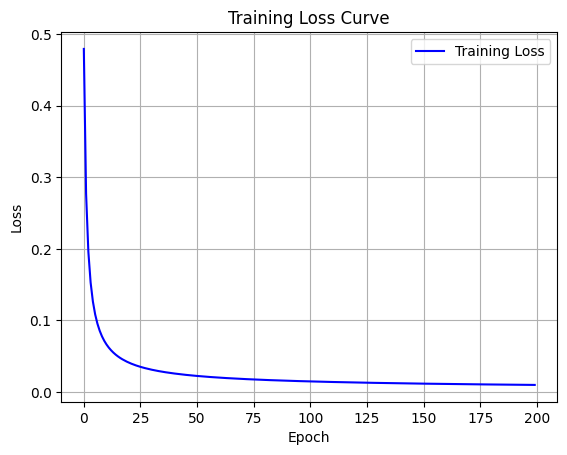

Training done!
Test Accuracy: 99.80%
Test Cross-Entropy Loss: 0.0097

Testing lr:0.01
Epoch 1, Loss: 0.1685252561
Epoch 51, Loss: 0.0056008406
Epoch 101, Loss: 0.0034895888
Epoch 151, Loss: 0.0025919086
Epoch 200, Loss: 0.0020850675


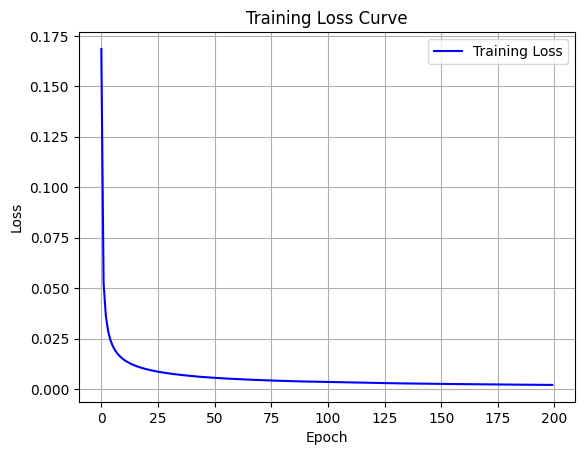

Training done!
Test Accuracy: 99.85%
Test Cross-Entropy Loss: 0.0048

Testing lr:0.1
Epoch 1, Loss: 0.0410411107
Epoch 51, Loss: 0.0009683233
Epoch 101, Loss: 0.0005238833
Epoch 151, Loss: 0.0003631658
Epoch 200, Loss: 0.0002801072


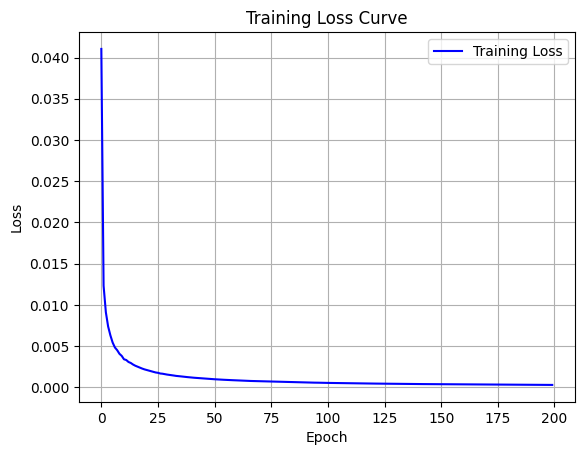

Training done!
Test Accuracy: 99.85%
Test Cross-Entropy Loss: 0.0047

Testing lr:1.0
Epoch 1, Loss: 0.0203921414
Epoch 51, Loss: 0.0001063081
Epoch 101, Loss: 0.0000568385
Epoch 151, Loss: 0.0000390299
Epoch 200, Loss: 0.0000299526


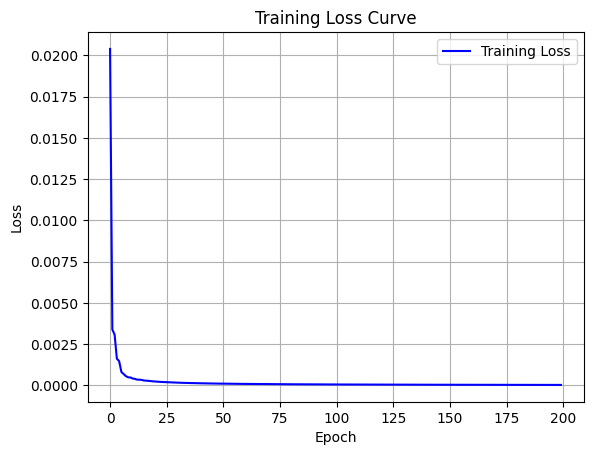

Training done!
Test Accuracy: 99.85%
Test Cross-Entropy Loss: 0.0058

Best learning rate: 1.000e-01    Validation CE: 0.004724


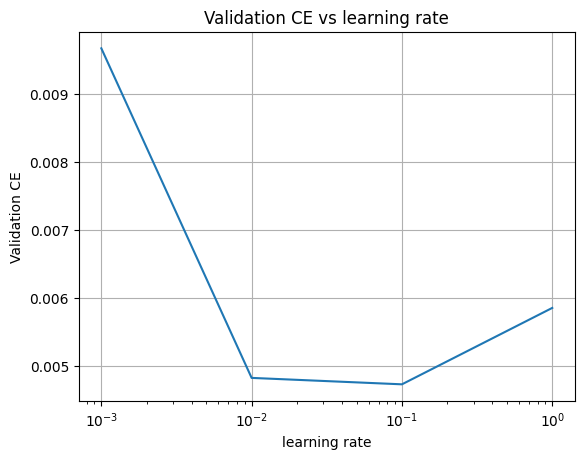

In [26]:
best_logistic_lr = validate(train_func= train_logistic, test_func=test_logistic_model,
                  train_loader=train_loader_binary,val_loader=val_loader_binary,
                  epochs = 200,plot=True)

In [29]:
W, b = train_logistic(train_loader_binary,lr=best_logistic_lr)
test_logistic_model(W,b,test_loader=test_loader_binary,cm_print=True)

Epoch 1, Loss: 0.0402241012
Epoch 26, Loss: 0.0017295589
Epoch 51, Loss: 0.0009692959
Epoch 76, Loss: 0.0006758120
Epoch 100, Loss: 0.0005292436
Training done!
Test Accuracy: 99.81%
Test Cross-Entropy Loss: 0.0033
Confusion Matrix:
 [[ 978    2]
 [   2 1133]]


0.003342742101691075

# Manual Implementations of everything Softmax

In [31]:
def softmax_manual(z):
    # subtract max for numerical stability
    z_exp = torch.exp(z - torch.max(z, dim=1, keepdim=True).values)
    return z_exp / torch.sum(z_exp, dim=1, keepdim=True)

In [32]:
def cross_entropy_softmax(y_pred, y_true):
    # y_true is [batch], y_pred is [batch, num_classes]
    # Gather predicted probability for the correct class
     return-torch.mean(torch.log(y_pred[torch.arange(len(y_true)), y_true] + 1e-8))

# Softmax Training

In [33]:
def train_softmax(train_loader,epochs,lr,plot=False):
  # Initialize parameters
  W = torch.zeros(784, 10, dtype=torch.float32, device=device, requires_grad=True)
  b = torch.zeros(10, dtype=torch.float32, device=device, requires_grad=True)
  train_losses, val_losses = [], []
  for epoch in range(epochs):
      epoch_loss = 0.0

      for x_batch, y_batch in train_loader:
          x_batch = x_batch.to(device)
          y_batch = y_batch.to(device, dtype=torch.long)

          # Forward pass
          y_pred = softmax_manual(x_batch @ W + b)

          # Loss
          loss = cross_entropy_softmax(y_pred, y_batch)

          # Backward
          loss.backward()

          # Update
          with torch.no_grad():
              W -= lr * W.grad
              b -= lr * b.grad
          W.grad.zero_()
          b.grad.zero_()

          epoch_loss += loss.item() * x_batch.size(0)

      train_loss = epoch_loss / len(train_loader.dataset)
      train_losses.append(train_loss)

      if (epoch/epochs*100)%25 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch+1}, Loss: {train_loss:.10f}")
        #print("Pred mean:", y_pred.mean().item())
        #print(f"Grad mean: {W.grad.abs().mean().item():.10f}")
  if plot:
    plt.plot(train_losses, label="Training Loss", color='blue')
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()
  print("Training done!")
  return W, b

Epoch 1, Loss: 1.7187209983
Epoch 26, Loss: 0.4041545543
Epoch 51, Loss: 0.3476781429
Epoch 76, Loss: 0.3211520865
Epoch 100, Loss: 0.3049123026


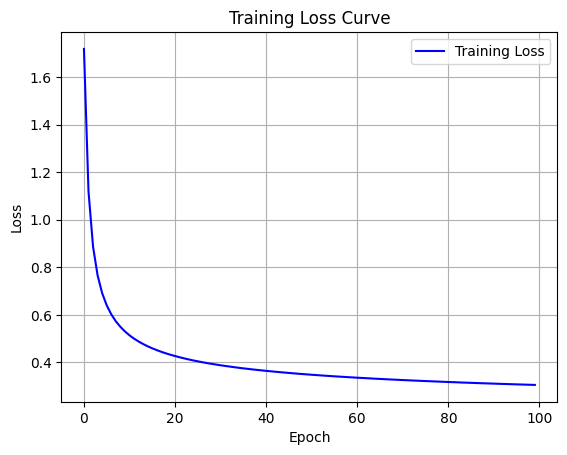

Training done!


(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True),
 tensor([-0.1893,  0.2821, -0.0440, -0.1434,  0.0405,  0.6082, -0.0607,  0.3274,
         -0.6935, -0.1273], requires_grad=True))

In [34]:
train_softmax(train_loader,epochs = 100, lr = 0.01,plot = True)

#Test Softmax

In [35]:
def test_softmax(W, b, test_loader,cm_print = True):
    W = W.to(device)
    b = b.to(device)
    total = 0
    correct = 0
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device, dtype=torch.long)

            y_pred = softmax_manual(x_batch @ W + b)

            loss = cross_entropy_softmax(y_pred, y_batch)
            total_loss += loss.item() * x_batch.size(0)

            preds = torch.argmax(y_pred, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    accuracy = correct / total
    mean_loss = total_loss / len(test_loader.dataset)

    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print(f"Test Cross-Entropy Loss: {mean_loss:.4f}")

    if cm_print:
    # Confusion Matrix
      cm = confusion_matrix(torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy())
      print("Confusion Matrix:\n", cm)
    return mean_loss

Testing lr:0.001
Epoch 1, Loss: 2.2213622069
Epoch 126, Loss: 0.4860644608
Epoch 251, Loss: 0.4050737583
Epoch 376, Loss: 0.3693560656
Epoch 500, Loss: 0.3477661617


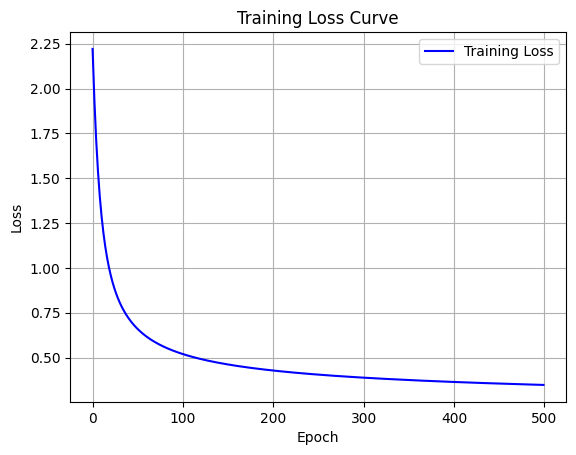

Training done!
Test Accuracy: 89.59%
Test Cross-Entropy Loss: 0.3696
Confusion Matrix:
 [[4731    0   17   15    9   40   38    4   54    8]
 [   1 5418   25   24    4   27    4   15   68   10]
 [  56   84 4211   96  115   21  100   83  150   29]
 [  29   33  106 4449    5  184   29   65  126   63]
 [  16   27   34    2 4390    6   56    9   29  280]
 [  84   51   29  231   66 3660   85   27  202   64]
 [  46   27   43    7   41   88 4618    1   39    2]
 [  42   61   82   14   61    9    3 4715   18  195]
 [  29  131   62  162   25  166   46   30 4115   90]
 [  43   25   35   81  195   33    5  173   41 4307]]

Testing lr:0.01
Epoch 1, Loss: 1.7185468839
Epoch 126, Loss: 0.2922617640
Epoch 251, Loss: 0.2585423545
Epoch 376, Loss: 0.2405567800
Epoch 500, Loss: 0.2282302243


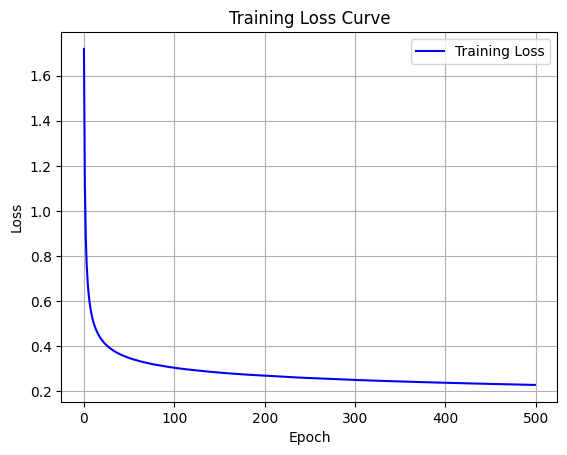

Training done!
Test Accuracy: 90.98%
Test Cross-Entropy Loss: 0.3122
Confusion Matrix:
 [[4752    2   14   18    7   49   26    4   38    6]
 [   2 5420   22   19    6   18    5   16   76   12]
 [  55   64 4323  104   86   24   80   67  123   19]
 [  21   29  114 4514    5  151   18   58  124   55]
 [  18   27   45    3 4445    7   51   13   29  211]
 [  68   34   41  183   58 3817   82   27  143   46]
 [  50   21   39    1   47   76 4651    5   22    0]
 [  26   34   76   15   46    9    3 4801   16  174]
 [  31  111   78  157   23  135   43   21 4182   75]
 [  30   23   24   66  155   27    4  162   46 4401]]

Testing lr:0.1
Epoch 1, Loss: 0.8241642388
Epoch 126, Loss: 0.1927763012
Epoch 251, Loss: 0.1628158610
Epoch 376, Loss: 0.1449999104
Epoch 500, Loss: 0.1329006765


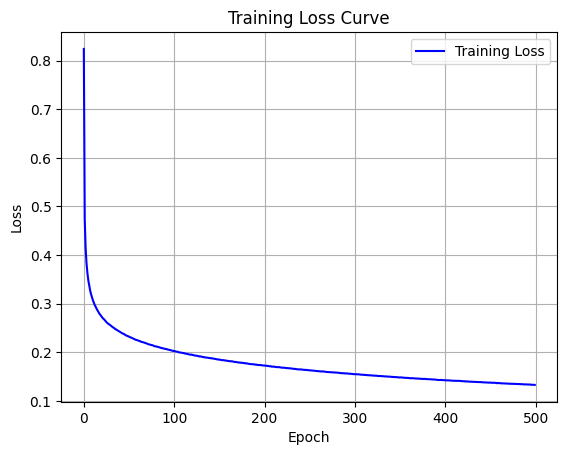

Training done!
Test Accuracy: 89.84%
Test Cross-Entropy Loss: 0.3803
Confusion Matrix:
 [[4700    2   23   20    7   80   32   11   34    7]
 [   2 5417   28   20    8   20    5   15   68   13]
 [  51   55 4316  119   78   46   69   63  128   20]
 [  31   33  158 4402    8  184   20   65  124   64]
 [  27   21   51    5 4409   18   50   27   34  207]
 [  74   39   58  180   51 3775   87   25  146   64]
 [  57   14   70    7   48   78 4613    1   21    3]
 [  18   34   74   27   42   15    4 4760   22  204]
 [  42  128  118  196   33  194   45   24 4006   70]
 [  26   26   24   67  173   43    4  186   45 4344]]

Testing lr:1.0
Epoch 1, Loss: 0.6556198005
Epoch 126, Loss: 0.1144660581
Epoch 251, Loss: 0.0792429821
Epoch 376, Loss: 0.0602324976
Epoch 500, Loss: 0.0494163839


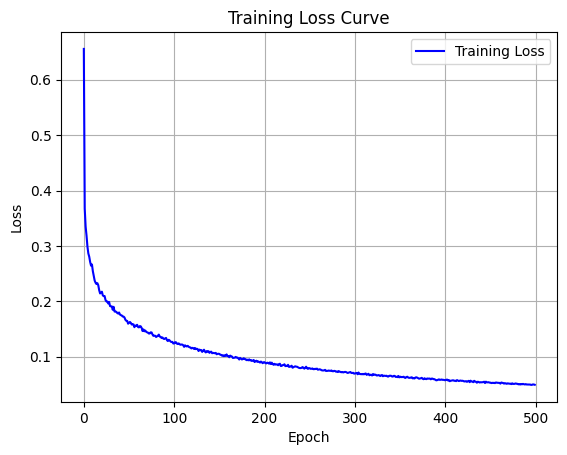

Training done!
Test Accuracy: 87.55%
Test Cross-Entropy Loss: 0.7258
Confusion Matrix:
 [[4602    3   45   36    7  135   37    9   34    8]
 [   1 5363   47   37   10   21    5   22   78   12]
 [  50   63 4214  185   75   62   86   63  125   22]
 [  34   43  164 4343   11  202   24   60  130   78]
 [  43   21   46   13 4352   38   44   43   26  223]
 [ 102   41   80  187   62 3674  102   26  147   78]
 [  66   25   96   18   61  125 4493    4   20    4]
 [  14   34   74   33   48   22    4 4717   15  239]
 [  54  148  184  277   41  300   50   38 3671   93]
 [  26   20   25   85  231   68    6  254   51 4172]]

Best learning rate: 1.000e-02    Validation CE: 0.312166


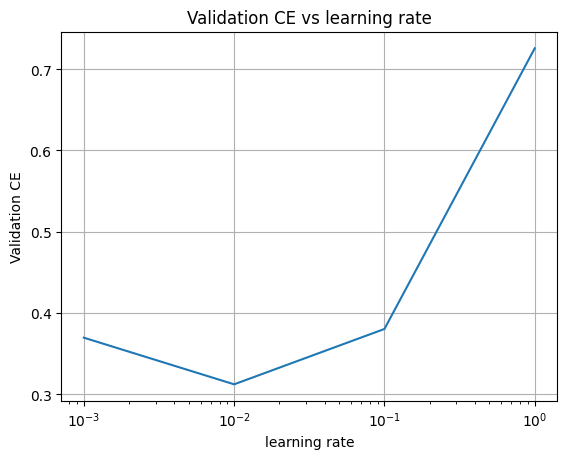

In [36]:
best_softmax_lr = validate(train_func=train_softmax,test_func=test_softmax,
         train_loader=train_loader,val_loader=val_loader,
         epochs = 500, plot=True
         )

In [37]:
W, b = train_softmax(train_loader,epochs = 200, lr=best_softmax_lr)
test_softmax(W = W,b = b,test_loader=test_loader,cm_print=True)

Epoch 1, Loss: 1.7183180349
Epoch 51, Loss: 0.3477160944
Epoch 101, Loss: 0.3043649721
Epoch 151, Loss: 0.2829167800
Epoch 200, Loss: 0.2691098964
Training done!
Test Accuracy: 91.10%
Test Cross-Entropy Loss: 0.3061
Confusion Matrix:
 [[ 959    0    3    2    0    7    6    1    2    0]
 [   0 1106    2    2    1    1    4    2   17    0]
 [  11   12  900   19    9    3   16   13   41    8]
 [   5    1   21  911    1   23    2   14   23    9]
 [   3    3    6    1  903    2   10    4    3   47]
 [  11    4    6   46    9  748   14    7   38    9]
 [  14    3    8    1   13   16  898    3    2    0]
 [   2   10   25    5    7    1    0  938    2   38]
 [   9   12   10   26    9   30    9   13  848    8]
 [  11    6    4   12   38    5    0   25    9  899]]


0.3061267949819565